In [24]:
# 统一论文图的风格和尺寸, 方便后续拼接
import os
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm   # 修改 1：新增，用于手动加载 Arial.ttf


# =========================
# 修改 2：只需要改这里
# =========================
ARIAL_TTF_PATH = "/data/jychen/package/Arial/arial.ttf"   # 改成你的 arial.ttf 实际路径
USE_ARIAL_TTF = True                # True = 从 ttf 文件加载 Arial；False = 直接用系统字体名


_PUB_FONT_NAME = None


def load_pub_font():
    """
    手动加载 Arial.ttf，并返回字体在 matplotlib 中识别到的真实名称。
    这样可以避免系统装了 Arial 但 matplotlib 仍然找不到的问题。
    """
    global _PUB_FONT_NAME

    if _PUB_FONT_NAME is not None:
        return _PUB_FONT_NAME

    if USE_ARIAL_TTF:
        if not os.path.exists(ARIAL_TTF_PATH):
            raise FileNotFoundError(f"找不到 Arial 字体文件: {ARIAL_TTF_PATH}")

        fm.fontManager.addfont(ARIAL_TTF_PATH)
        _PUB_FONT_NAME = fm.FontProperties(fname=ARIAL_TTF_PATH).get_name()
    else:
        _PUB_FONT_NAME = "Arial"

    print(f"Using font: {_PUB_FONT_NAME}")
    return _PUB_FONT_NAME


def mm_to_inch(mm):
    return mm / 25.4


FIG_SIZE = {
    "single": 90,
    "double": 180,
}


FIG_PRESETS = {
    "single_small":  ("single", 60),
    "single_short": ("single", 75),
    "double_short":  ("double", 70),
    "double_short": ("double", 100),
    "double_large":  ("double", 140),
}


_SHARED_FONT_SIZES = {
    "font.size": 9,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 10,
}


def set_pub_style():
    pub_font = load_pub_font()   # 修改 3：每次设置风格前，先确保 Arial.ttf 已经加载

    base = {
        # 修改 4：不再直接写死 "Arial"，而是使用 ttf 文件真实识别到的字体名
        "font.family": pub_font,
        "font.sans-serif": [pub_font, "Arial", "Helvetica", "Liberation Sans", "DejaVu Sans"],

        "font.weight": "normal",
        "axes.labelweight": "normal",
        "axes.titleweight": "normal",

        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "svg.fonttype": "none",

        # 稍粗一些的论文图风格
        "axes.linewidth": 1.5,
        "xtick.major.width": 1.4,
        "ytick.major.width": 1.4,
        "xtick.minor.width": 1.1,
        "ytick.minor.width": 1.1,
        "xtick.major.size": 4.5,
        "ytick.major.size": 4.5,
        "xtick.minor.size": 2.8,
        "ytick.minor.size": 2.8,
        "xtick.direction": "in",
        "ytick.direction": "in",

        "lines.linewidth": 1.7,
        "patch.linewidth": 1.3,

        "legend.frameon": False,
        "legend.handlelength": 1.5,
        "legend.handletextpad": 0.4,

        "axes.unicode_minus": False,
        "axes.spines.top": True,
        "axes.spines.right": True,

        "savefig.dpi": 600,
        "figure.dpi": 120,
    }

    base.update(_SHARED_FONT_SIZES)
    mpl.rcParams.update(base)


def new_figure(mode="single", height_mm=65):
    set_pub_style()
    width_mm = FIG_SIZE[mode]
    fig, ax = plt.subplots(
        figsize=(mm_to_inch(width_mm), mm_to_inch(height_mm))
    )
    return fig, ax


def new_subplots(nrows, ncols, preset="double_medium", **kwargs):
    set_pub_style()
    mode, height_mm = FIG_PRESETS[preset]
    width_mm = FIG_SIZE[mode]

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(mm_to_inch(width_mm), mm_to_inch(height_mm)),
        **kwargs
    )
    return fig, axes


def savefig_pub(fig, filename, dpi=600, tight=False):
    if tight:
        fig.savefig(filename, dpi=dpi, bbox_inches="tight", pad_inches=0.02)
    else:
        fig.savefig(filename, dpi=dpi)


# 应用统一风格模板
set_pub_style()

Using font: Arial


[跳过计算] 检测到已有数据文件: /data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Analysis/rdf/segment_density_IDP_v2.txt
[保存图片] /data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Analysis/rdf/segment_density_IDP_v2.png

[完成] 已使用缓存数据绘图。


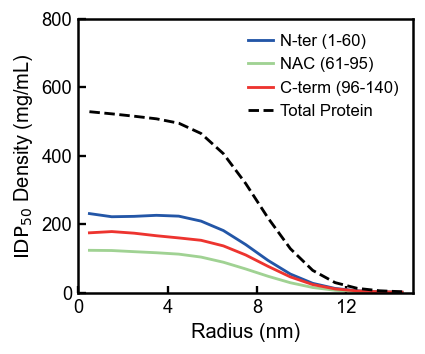

In [28]:
import matplotlib as mpl
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from pathlib import Path

# ===================== 用户设置 =====================
topology = '/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/W_cluster/alhx_0/TR_Mdvwhole/pbc.tpr'
trajectory_files = [
    '/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/W_cluster/alhx_0/TR_Mdvwhole/clus_centered.xtc',
    '/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/W_cluster/alhx_0_re1/TR_Mdvwhole/clus_centered.xtc',
    '/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/W_cluster/alhx_0_re2/TR_Mdvwhole/clus_centered.xtc',
]

# --- 帧数范围筛选设置 ---
# 注意：Python 索引从 0 开始。10000帧表示从第10001个数据点开始。
# 如果想计算全部，可以将 FRAME_END 设为 None
FRAME_START = 10000  
FRAME_END = None   
# ----------------------

RESIDUES_PER_CHAIN = 140
TARGET_SEGMENTS = {
    'N-ter (1-60)':   (1, 60),    # H1 + H2 合并
    'NAC (61-95)':    (61, 95),
    'C-term (96-140)':(96, 140),
}

r_max = 150.0             
n_bins = 15               # 增加到了50，使曲线更平滑
CONVERSION_FACTOR = 1660.54 

# ====================================================

bins = np.linspace(0, r_max, n_bins + 1)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
volumes = 4/3 * np.pi * (bins[1:]**3 - bins[:-1]**3)

# ===================== 平均与绘图 =====================
# 使用 cell1 中定义的统一论文图模板：single_short = 90 mm x 60 mm
FIG_PRESET = "single_short"
output_txt = Path('/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Analysis/rdf/segment_density_IDP_v2.txt')
output_png = output_txt.with_suffix(".png")
colors = ["#2356A7", "#A0D293", "#ED342F"]

def format_density_axes(ax):
    ax.set_xlabel("Radius (nm)")
    ax.set_ylabel(r"$\text{IDP}_{50}$ Density (mg/mL)")
    ax.legend(loc="upper right")
    ax.grid(False)
    ax.set_xlim(0, r_max/10)
    ax.set_ylim(0, 800)
    ax.tick_params(top=False, right=False)
    ax.xaxis.set_major_locator(MaxNLocator(nbins=4))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=4))

def plot_density_data(data):
    fig, ax = new_subplots(1, 1, preset=FIG_PRESET)
    segment_names = list(TARGET_SEGMENTS)
    
    for i, name in enumerate(segment_names):
        if data.shape[1] <= i + 1:
            continue
        ax.plot(
            data[:, 0],
            data[:, i + 1],
            label=name,
            lw=mpl.rcParams["lines.linewidth"],
            color=colors[i],
        )
    
    if data.shape[1] > 1:
        total_density = np.sum(data[:, 1:], axis=1)
        ax.plot(data[:, 0], total_density, label="Total Protein", color="black", lw=mpl.rcParams["lines.linewidth"], ls="--")
    
    format_density_axes(ax)
    fig.tight_layout(pad=0.8)
    savefig_pub(fig, output_png, tight=True)
    print(f"[保存图片] {output_png}")
    return fig, ax

has_cached = output_txt.exists() and output_txt.stat().st_size > 0

if has_cached:
    print(f"[跳过计算] 检测到已有数据文件: {output_txt}")
    data = np.atleast_2d(np.loadtxt(output_txt))
    fig, ax = plot_density_data(data)
    print("\n[完成] 已使用缓存数据绘图。")
    plt.show()
else:
    import MDAnalysis as mda
    from tqdm import tqdm

    results_storage = {name: [] for name in TARGET_SEGMENTS}

    for traj_file in trajectory_files:
        print(f"\n=== 处理轨迹文件: {traj_file} ===")
        try:
            u = mda.Universe(topology, traj_file)
        except Exception as e:
            print(f"无法加载文件 {traj_file}: {e}")
            continue

        # 确定实际切片范围
        total_frames = len(u.trajectory)
        actual_start = max(0, FRAME_START)
        actual_end = min(total_frames, FRAME_END) if FRAME_END is not None else total_frames

        if actual_start >= total_frames:
            print(f"警告：设定起始帧({actual_start})超过轨迹总帧数({total_frames})，跳过此文件。")
            continue
        
        print(f"该轨迹总帧数: {total_frames}, 将计算范围: {actual_start} 至 {actual_end} (共 {actual_end - actual_start} 帧)")

        # --- 识别链逻辑 ---
        protein_atoms = u.select_atoms("protein")
        all_res = protein_atoms.residues
        n_total_res = len(all_res)
        n_chains = n_total_res // RESIDUES_PER_CHAIN
        
        seg_info = {}
        for name, (start_res, end_res) in TARGET_SEGMENTS.items():
            combined_atoms = mda.AtomGroup([], u)
            for i in range(n_chains):
                chain_offset = i * RESIDUES_PER_CHAIN
                idx_start = chain_offset + (start_res - 1)
                idx_end = chain_offset + end_res
                combined_atoms += all_res[idx_start : idx_end].atoms
            
            seg_info[name] = {
                "atoms": combined_atoms,
                "masses": combined_atoms.masses,
                "counts": np.zeros(n_bins, dtype=float),
            }

        frame_count = 0
        # 使用切片功能 [actual_start:actual_end]
        for ts in tqdm(u.trajectory[actual_start:actual_end], desc="计算中", unit="frame"):
            current_origin = protein_atoms.center_of_mass()
            
            for name in TARGET_SEGMENTS:
                atoms = seg_info[name]["atoms"]
                masses = seg_info[name]["masses"]
                distances = np.linalg.norm(atoms.positions - current_origin, axis=1)
                hist, _ = np.histogram(distances, bins=bins, weights=masses)
                seg_info[name]["counts"] += hist
                
            frame_count += 1

        if frame_count > 0:
            for name in TARGET_SEGMENTS:
                avg_mass_in_bins = seg_info[name]["counts"] / frame_count
                density_da_a3 = avg_mass_in_bins / volumes
                density_mg_ml = density_da_a3 * CONVERSION_FACTOR
                results_storage[name].append(density_mg_ml)

    fig, ax = new_subplots(1, 1, preset=FIG_PRESET)
    data_to_save = [bin_centers / 10]
    header = "Radius(nm)"

    for i, (name, profiles_list) in enumerate(results_storage.items()):
        if not profiles_list:
            continue
        profiles_array = np.array(profiles_list)
        mean_density = np.mean(profiles_array, axis=0)
        std_density = np.std(profiles_array, axis=0)
        
        ax.plot(bin_centers / 10, mean_density, label=name, lw=mpl.rcParams["lines.linewidth"], color=colors[i])
        if len(profiles_list) > 1:
            ax.fill_between(bin_centers / 10, mean_density - std_density, mean_density + std_density, color=colors[i], alpha=0.2)
        
        data_to_save.append(mean_density)
        header += f"	{name.split()[0]}(mg/ml)"

    # 绘制总密度参考线
    if results_storage["N-ter (1-60)"]:
        total_density = np.sum([np.mean(np.array(v), axis=0) for v in results_storage.values() if v], axis=0)
        ax.plot(bin_centers / 10, total_density, label="Total Protein", color="black", lw=mpl.rcParams["lines.linewidth"], ls="--")
    
    format_density_axes(ax)
    fig.tight_layout(pad=0.8)

    np.savetxt(output_txt, np.column_stack(data_to_save), header=header, fmt="%.4f")
    savefig_pub(fig, output_png, tight=True)
    print(f"\n[完成] 结果已保存: {output_txt}")
    print(f"[保存图片] {output_png}")
    plt.show()


[跳过计算] 检测到已有数据文件: /data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Analysis/rdf/segment_density_Helix_v2.txt
[保存图片] /data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Analysis/rdf/segment_density_Helix_v2.png

[完成] 已使用缓存数据绘图。


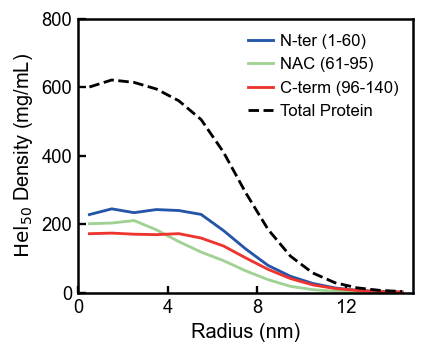

In [29]:
import matplotlib as mpl
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from pathlib import Path

# ===================== 用户设置 =====================
topology = '/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/W_cluster/alhx_700/TR_Mdvwhole/pbc.tpr'
trajectory_files = [
    '/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/W_cluster/alhx_700/TR_Mdvwhole/clus_centered.xtc',
    '/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/W_cluster/alhx_700_re1/TR_Mdvwhole/clus_centered.xtc',
    '/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/W_cluster/alhx_700_re2/TR_Mdvwhole/clus_centered.xtc',
]

# --- 帧数范围筛选设置 ---
# 注意：Python 索引从 0 开始。10000帧表示从第10001个数据点开始。
# 如果想计算全部，可以将 FRAME_END 设为 None
FRAME_START = 10000  
FRAME_END = None   
# ----------------------

RESIDUES_PER_CHAIN = 140
TARGET_SEGMENTS = {
    'N-ter (1-60)':   (1, 60),    # H1 + H2 合并
    'NAC (61-95)':    (61, 95),
    'C-term (96-140)':(96, 140),
}

r_max = 150.0             
n_bins = 15               # 增加到了50，使曲线更平滑
CONVERSION_FACTOR = 1660.54 

# ====================================================

bins = np.linspace(0, r_max, n_bins + 1)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
volumes = 4/3 * np.pi * (bins[1:]**3 - bins[:-1]**3)

# ===================== 平均与绘图 =====================
# 使用 cell1 中定义的统一论文图模板：single_short = 90 mm x 60 mm
FIG_PRESET = "single_short"
output_txt = Path('/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Analysis/rdf/segment_density_Helix_v2.txt')
output_png = output_txt.with_suffix(".png")
colors = ["#2356A7", "#A0D293", "#ED342F"]

def format_density_axes(ax):
    ax.set_xlabel("Radius (nm)")
    ax.set_ylabel(r"$\text{Hel}_{50}$ Density (mg/mL)")
    ax.legend(loc="upper right")
    ax.grid(False)
    ax.set_xlim(0, r_max/10)
    ax.set_ylim(0, 800)
    ax.tick_params(top=False, right=False)
    ax.xaxis.set_major_locator(MaxNLocator(nbins=4))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=4))

def plot_density_data(data):
    fig, ax = new_subplots(1, 1, preset=FIG_PRESET)
    segment_names = list(TARGET_SEGMENTS)
    
    for i, name in enumerate(segment_names):
        if data.shape[1] <= i + 1:
            continue
        ax.plot(
            data[:, 0],
            data[:, i + 1],
            label=name,
            lw=mpl.rcParams["lines.linewidth"],
            color=colors[i],
        )
    
    if data.shape[1] > 1:
        total_density = np.sum(data[:, 1:], axis=1)
        ax.plot(data[:, 0], total_density, label="Total Protein", color="black", lw=mpl.rcParams["lines.linewidth"], ls="--")
    
    format_density_axes(ax)
    fig.tight_layout(pad=0.8)
    savefig_pub(fig, output_png, tight=True)
    print(f"[保存图片] {output_png}")
    return fig, ax

has_cached = output_txt.exists() and output_txt.stat().st_size > 0

if has_cached:
    print(f"[跳过计算] 检测到已有数据文件: {output_txt}")
    data = np.atleast_2d(np.loadtxt(output_txt))
    fig, ax = plot_density_data(data)
    print("\n[完成] 已使用缓存数据绘图。")
    plt.show()
else:
    import MDAnalysis as mda
    from tqdm import tqdm

    results_storage = {name: [] for name in TARGET_SEGMENTS}

    for traj_file in trajectory_files:
        print(f"\n=== 处理轨迹文件: {traj_file} ===")
        try:
            u = mda.Universe(topology, traj_file)
        except Exception as e:
            print(f"无法加载文件 {traj_file}: {e}")
            continue

        # 确定实际切片范围
        total_frames = len(u.trajectory)
        actual_start = max(0, FRAME_START)
        actual_end = min(total_frames, FRAME_END) if FRAME_END is not None else total_frames

        if actual_start >= total_frames:
            print(f"警告：设定起始帧({actual_start})超过轨迹总帧数({total_frames})，跳过此文件。")
            continue
        
        print(f"该轨迹总帧数: {total_frames}, 将计算范围: {actual_start} 至 {actual_end} (共 {actual_end - actual_start} 帧)")

        # --- 识别链逻辑 ---
        protein_atoms = u.select_atoms("protein")
        all_res = protein_atoms.residues
        n_total_res = len(all_res)
        n_chains = n_total_res // RESIDUES_PER_CHAIN
        
        seg_info = {}
        for name, (start_res, end_res) in TARGET_SEGMENTS.items():
            combined_atoms = mda.AtomGroup([], u)
            for i in range(n_chains):
                chain_offset = i * RESIDUES_PER_CHAIN
                idx_start = chain_offset + (start_res - 1)
                idx_end = chain_offset + end_res
                combined_atoms += all_res[idx_start : idx_end].atoms
            
            seg_info[name] = {
                "atoms": combined_atoms,
                "masses": combined_atoms.masses,
                "counts": np.zeros(n_bins, dtype=float),
            }

        frame_count = 0
        # 使用切片功能 [actual_start:actual_end]
        for ts in tqdm(u.trajectory[actual_start:actual_end], desc="计算中", unit="frame"):
            current_origin = protein_atoms.center_of_mass()
            
            for name in TARGET_SEGMENTS:
                atoms = seg_info[name]["atoms"]
                masses = seg_info[name]["masses"]
                distances = np.linalg.norm(atoms.positions - current_origin, axis=1)
                hist, _ = np.histogram(distances, bins=bins, weights=masses)
                seg_info[name]["counts"] += hist
                
            frame_count += 1

        if frame_count > 0:
            for name in TARGET_SEGMENTS:
                avg_mass_in_bins = seg_info[name]["counts"] / frame_count
                density_da_a3 = avg_mass_in_bins / volumes
                density_mg_ml = density_da_a3 * CONVERSION_FACTOR
                results_storage[name].append(density_mg_ml)

    fig, ax = new_subplots(1, 1, preset=FIG_PRESET)
    data_to_save = [bin_centers / 10]
    header = "Radius(nm)"

    for i, (name, profiles_list) in enumerate(results_storage.items()):
        if not profiles_list:
            continue
        profiles_array = np.array(profiles_list)
        mean_density = np.mean(profiles_array, axis=0)
        std_density = np.std(profiles_array, axis=0)
        
        ax.plot(bin_centers / 10, mean_density, label=name, lw=mpl.rcParams["lines.linewidth"], color=colors[i])
        if len(profiles_list) > 1:
            ax.fill_between(bin_centers / 10, mean_density - std_density, mean_density + std_density, color=colors[i], alpha=0.2)
        
        data_to_save.append(mean_density)
        header += f"	{name.split()[0]}(mg/ml)"

    # 绘制总密度参考线
    if results_storage["N-ter (1-60)"]:
        total_density = np.sum([np.mean(np.array(v), axis=0) for v in results_storage.values() if v], axis=0)
        ax.plot(bin_centers / 10, total_density, label="Total Protein", color="black", lw=mpl.rcParams["lines.linewidth"], ls="--")
    
    format_density_axes(ax)
    fig.tight_layout(pad=0.8)

    np.savetxt(output_txt, np.column_stack(data_to_save), header=header, fmt="%.4f")
    savefig_pub(fig, output_png, tight=True)
    print(f"\n[完成] 结果已保存: {output_txt}")
    print(f"[保存图片] {output_png}")
    plt.show()
